# Tuần 07 — Thực hành k-Means: 3 bài

Demo `03_Demo-kMeans.ipynb` gom cụm bằng tay trên dữ liệu giả 2 chiều.

File này có **3 bài**. Mỗi bài là một bộ dữ liệu thật trên Kaggle. Cả 3 bài đều làm. Dùng `sklearn.cluster.KMeans`.

Clustering không chia train/test và không có nhãn để học. `StandardScaler` fit trên toàn bộ bảng feature. Không đưa cột ID hay tên vào khoảng cách.

Tải 3 file vào `data/`:

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Mall Customer Segmentation | https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python | `data/Mall_Customers.csv` |
| 2 | Unsupervised Learning on Country Data | https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data | `data/Country-data.csv` |
| 3 | Wholesale Customers | https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set | `data/Wholesale customers data.csv` |

Ba bộ này cũng được dùng ở `09_TH-DBSCAN.ipynb`, để so sánh hai cách gom cụm trên cùng dữ liệu.


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)


## Phần chung

Elbow: với mỗi `K` từ 1 đến `k_max`, fit `KMeans` (`n_init=10`, `random_state=3000`), lưu `inertia_`, rồi vẽ. Chỗ khuỷu tay là `K` nên thử.

Sau khi có nhãn, bảng trung bình theo cụm giúp đọc ý nghĩa từng nhóm.


In [2]:
def ve_elbow(X_scaled, k_max=10):
    ks = list(range(1, k_max + 1))
    inertias = []
    for k in ks:
        model = KMeans(n_clusters=k, n_init=10, random_state=3000)
        model.fit(X_scaled)
        inertias.append(model.inertia_)
    plt.figure(figsize=(6, 4))
    plt.plot(ks, inertias, marker='o')
    plt.xlabel('K')
    plt.ylabel('inertia')
    plt.grid(True)
    plt.show()
    return ks, inertias


def bang_trung_binh(df_goc, labels, cot_so):
    tam = df_goc[cot_so].copy()
    tam['cum'] = labels
    return tam.groupby('cum').mean().round(2)

---

# Bài 1 — Khách hàng trung tâm thương mại

Nguồn: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

200 khách. Cột: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.

Bài này chỉ dùng **thu nhập** và **điểm chi tiêu**. Bỏ `CustomerID`. Không đưa `Gender` vào khoảng cách. Có thể để `Age` sang một lần chạy riêng nếu còn thời gian.

Chuẩn hóa hai cột, vẽ elbow, chọn `K`, tô màu scatter theo cụm. Dấu `x` là tâm cụm tính trên **số gốc** (trung bình thu nhập và điểm chi tiêu của các điểm trong cụm), để đọc được đơn vị thật.


Path to dataset files: C:\Users\DUC THANG\.cache\kagglehub\datasets\vjchoudhary7\customer-segmentation-tutorial-in-python\versions\1
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)


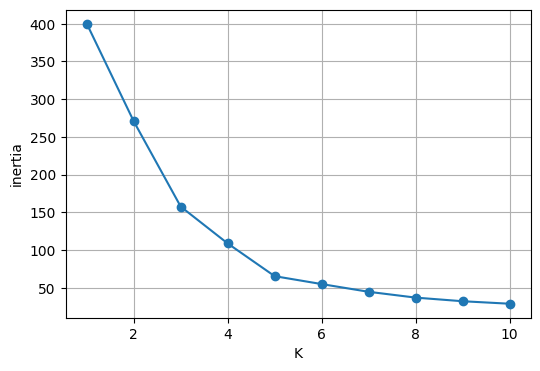

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [400.0,
  270.66820496844673,
  157.70400815035947,
  108.92131661364355,
  65.56840815571681,
  55.103778121150576,
  44.86628627232253,
  37.18175782682131,
  32.37724377444034,
  29.07617685124427])

In [12]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
print("Path to dataset files:", path)

mall = pd.read_csv(Path(path) / 'Mall_Customers.csv')
print(mall.head())
print(mall.shape)

cot = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mall[cot].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

ve_elbow(X_scaled)

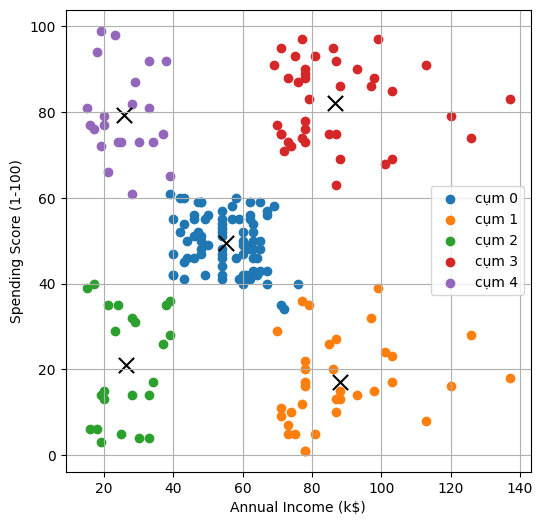

     Annual Income (k$)  Spending Score (1-100)
cum                                            
0                 55.30                   49.52
1                 88.20                   17.11
2                 26.30                   20.91
3                 86.54                   82.13
4                 25.73                   79.36
số điểm mỗi cụm: (array([0, 1, 2, 3, 4], dtype=int32), array([81, 35, 23, 39, 22]))


In [6]:
K = 5
model = KMeans(n_clusters=K, n_init=10, random_state=3000)
labels = model.fit_predict(X_scaled)

plt.figure(figsize=(6, 6))
for cum in np.unique(labels):
    pts = X[labels == cum]
    plt.scatter(pts[:, 0], pts[:, 1], label=f'cụm {cum}')
    plt.scatter(pts[:, 0].mean(), pts[:, 1].mean(), c='black', marker='x', s=120)
plt.xlabel(cot[0])
plt.ylabel(cot[1])
plt.legend()
plt.grid(True)
plt.show()

print(bang_trung_binh(mall, labels, cot))
print('số điểm mỗi cụm:', np.unique(labels, return_counts=True))

**Nộp kèm bài 1**

1. `K` bạn chọn là bao nhiêu? Elbow gãy ở đâu?
2. Mô tả từng cụm bằng thu nhập và điểm chi tiêu (cao / thấp). Cụm nào đáng ưu tiên cho khuyến mãi?
3. Nếu thêm cột `Age` vào `X` rồi chuẩn hóa lại, bạn có đổi `K` không?


Elbow được chọn tại K=5; cụm có spending score trung bình cao nhất là 3.
     Annual Income (k$)  Spending Score (1-100)
cum                                            
0                 55.30                   49.52
1                 88.20                   17.11
2                 26.30                   20.91
3                 86.54                   82.13
4                 25.73                   79.36
Ưu tiên cụm có spending score cao; đối chiếu thêm income để chọn nhóm phù hợp cho khuyến mãi.
Elbow khi thêm Age:


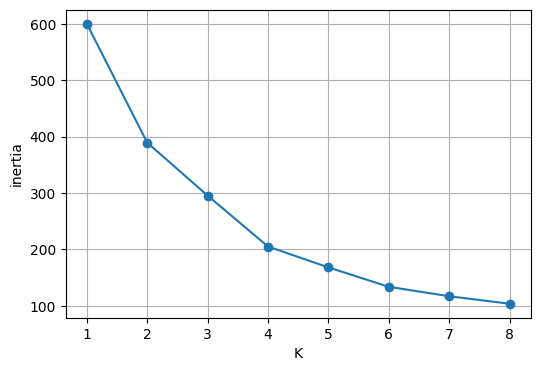

([1, 2, 3, 4, 5, 6, 7, 8],
 [600.0,
  389.3861889564372,
  295.5019546135399,
  205.22514747675913,
  168.24758017556837,
  133.86833362685584,
  117.12594802177425,
  103.8462382427777])

In [7]:
cluster_means = bang_trung_binh(mall, labels, cot)
promo_cluster = cluster_means['Spending Score (1-100)'].idxmax()
print(f'Elbow được chọn tại K={K}; cụm có spending score trung bình cao nhất là {promo_cluster}.')
print(cluster_means)
print('Ưu tiên cụm có spending score cao; đối chiếu thêm income để chọn nhóm phù hợp cho khuyến mãi.')

X_with_age = mall[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].to_numpy(dtype=float)
print('Elbow khi thêm Age:')
ve_elbow(StandardScaler().fit_transform(X_with_age), k_max=8)

---

# Bài 2 — Phân nhóm quốc gia

Nguồn: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data

167 nước, file `Country-data.csv`. Cột `country` là tên, không đưa vào `X`.

Các cột số: `child_mort`, `exports`, `health`, `imports`, `income`, `inflation`, `life_expec`, `total_fer`, `gdpp`.

`income` và `gdpp` lớn hơn `child_mort` rất nhiều. Bắt buộc `StandardScaler`. Chọn `K` bằng elbow (thường thử quanh 3). In trung bình `child_mort`, `income`, `life_expec`, `gdpp` theo cụm, và liệt kê khoảng 8 tên nước mỗi cụm.


100%|██████████| 5.21k/5.21k [00:00<00:00, 2.45MB/s]

Extracting files...
Path to dataset files: C:\Users\DUC THANG\.cache\kagglehub\datasets\rohan0301\unsupervised-learning-on-country-data\versions\2
               country  child_mort  exports  health  imports  income  inflation  life_expec  total_fer   gdpp
0          Afghanistan        90.2     10.0    7.58     44.9    1610       9.44        56.2       5.82    553
1              Albania        16.6     28.0    6.55     48.6    9930       4.49        76.3       1.65   4090
2              Algeria        27.3     38.4    4.17     31.4   12900      16.10        76.5       2.89   4460
3               Angola       119.0     62.3    2.85     42.9    5900      22.40        60.1       6.16   3530
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100       1.44        76.8       2.13  12200
(167, 10)


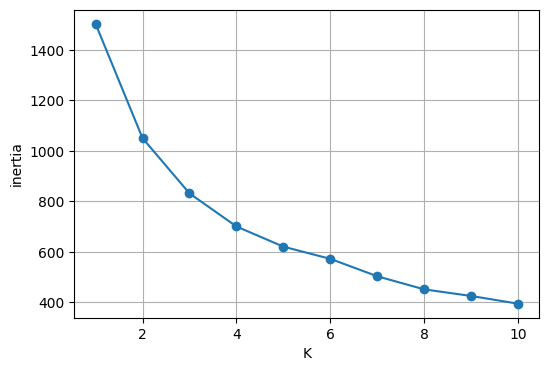

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [1503.0,
  1050.2145582853304,
  831.4244352086873,
  700.3917199643635,
  620.4488115302203,
  572.0890405033383,
  503.0948550735083,
  451.32364852916584,
  425.20634399408493,
  394.5676252504498])

In [8]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")
print("Path to dataset files:", path)

country = pd.read_csv(Path(path) / 'Country-data.csv')
print(country.head())
print(country.shape)

cot_so = [c for c in country.columns if c != 'country']
X_scaled = StandardScaler().fit_transform(country[cot_so].to_numpy(dtype=float))

ve_elbow(X_scaled)

In [9]:
K = 4
labels = KMeans(n_clusters=K, n_init=10, random_state=3000).fit_predict(X_scaled)

print(bang_trung_binh(country, labels, ['child_mort', 'income', 'life_expec', 'gdpp']))

for cum in np.unique(labels):
    ten = country.loc[labels == cum, 'country'].head(8).tolist()
    print(cum, ten)

     child_mort    income  life_expec      gdpp
cum                                            
0          4.95  45250.00       80.38  43333.33
1         21.74  12972.39       72.76   6912.64
2         93.84   3738.98       59.23   1826.13
3          4.13  64033.33       81.43  57566.67
0 ['Australia', 'Austria', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Denmark', 'Finland']
1 ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bahrain']
2 ['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad']
3 ['Luxembourg', 'Malta', 'Singapore']


**Nộp kèm bài 2**

1. `K` bạn chọn? Cụm nào có `child_mort` cao và `gdpp` thấp?
2. Kể tên 3 nước thuộc cụm đó và 3 nước thuộc cụm có `gdpp` cao.
3. Vì sao không chuẩn hóa thì `income` và `gdpp` sẽ át các cột còn lại?


In [10]:
country_profile = bang_trung_binh(country, labels, ['child_mort', 'income', 'life_expec', 'gdpp'])
poor_cluster = country_profile.sort_values(['child_mort', 'gdpp'], ascending=[False, True]).index[0]
rich_cluster = country_profile['gdpp'].idxmax()
print(f'Cụm child_mort cao và gdpp thấp: {poor_cluster}')
print('Quốc gia đại diện:', country.loc[labels == poor_cluster, 'country'].head(3).tolist())
print(f'Cụm gdpp cao nhất: {rich_cluster}')
print('Quốc gia đại diện:', country.loc[labels == rich_cluster, 'country'].head(3).tolist())
print('Chuẩn hóa cần thiết vì income và gdpp có thang đo lớn hơn child_mort.')

Cụm child_mort cao và gdpp thấp: 2
Quốc gia đại diện: ['Afghanistan', 'Angola', 'Benin']
Cụm gdpp cao nhất: 3
Quốc gia đại diện: ['Luxembourg', 'Malta', 'Singapore']
Chuẩn hóa cần thiết vì income và gdpp có thang đo lớn hơn child_mort.


---

# Bài 3 — Khách sỉ

Nguồn: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set

440 khách hàng bán sỉ. File `Wholesale customers data.csv`.

Cột: `Channel`, `Region`, `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

`Channel` (1 = Horeca, 2 = Retail) và `Region` là mã nhóm, không phải số tiền. **Không** đưa hai cột này vào `X`. Gom cụm trên 6 cột chi tiêu, sau chuẩn hóa. Rồi dùng `pd.crosstab` để xem mỗi cụm nằm ở kênh nào.


Path to dataset files: C:\Users\DUC THANG\.cache\kagglehub\datasets\binovi\wholesale-customers-data-set\versions\1
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
(440, 8)


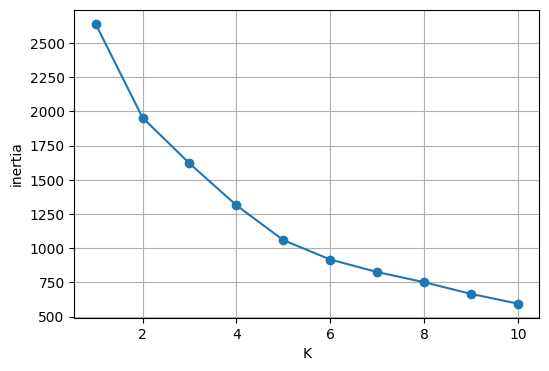

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [2640.0,
  1954.1835647259284,
  1619.9527821724562,
  1313.7580090341146,
  1058.7712532570083,
  917.4454350272308,
  825.8359775416384,
  751.7362093470331,
  666.2237996202155,
  594.8556455931526])

In [14]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("binovi/wholesale-customers-data-set")
print("Path to dataset files:", path)

ws = pd.read_csv(Path(path) / 'Wholesale customers data.csv')
print(ws.head())
print(ws.shape)

cot_chi = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X_scaled = StandardScaler().fit_transform(ws[cot_chi].to_numpy(dtype=float))

ve_elbow(X_scaled)

In [15]:
K = 4
labels = KMeans(n_clusters=K, n_init=10, random_state=3000).fit_predict(X_scaled)

print(bang_trung_binh(ws, labels, cot_chi))
print(pd.crosstab(labels, ws['Channel'], rownames=['cum'], colnames=['Channel']))

        Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
cum                                                                      
0    13599.16   3050.81   3857.97   3281.05            854.62     1168.96
1    15964.90  34708.50  48536.90   3054.60          24875.20     2942.80
2     5778.66  10350.05  15694.88   1532.84           6689.96     1892.10
3    60571.67  30120.33  17314.67  38049.33           2153.00    20700.67
Channel    1   2
cum             
0        278  38
1          0  10
2         17  94
3          3   0


**Nộp kèm bài 3**

1. `K` bạn chọn? Cụm nào chi mạnh cho `Grocery` và `Detergents_Paper`?
2. Cụm đó lệch về `Channel` nào trên bảng crosstab?
3. So với bài 1: vì sao bài 3 không vẽ một scatter là đủ để đọc cụm?


In [16]:
cluster_spending = bang_trung_binh(ws, labels, cot_chi)
strong_cluster = cluster_spending[['Grocery', 'Detergents_Paper']].mean(axis=1).idxmax()
channel_share = pd.crosstab(labels, ws['Channel'], normalize='index')
print(f'Cụm chi mạnh cho Grocery và Detergents_Paper: {strong_cluster}')
print('Channel chiếm ưu thế:', channel_share.loc[strong_cluster].idxmax())
print(channel_share.loc[strong_cluster])
print('Cần xem đồng thời sáu đặc trưng chi tiêu; scatter 2D không thể hiện đủ cấu trúc cụm.')

Cụm chi mạnh cho Grocery và Detergents_Paper: 1
Channel chiếm ưu thế: 2
Channel
1    0.0
2    1.0
Name: 1, dtype: float64
Cần xem đồng thời sáu đặc trưng chi tiêu; scatter 2D không thể hiện đủ cấu trúc cụm.
